# Dense periodic n=1: historical GC and signed-lag TDMI

## 0. Purpose of Notebook 01

This notebook uses the frozen dense-periodic n=1 simulation to teach how joint Granger-predictive evidence, individual distributed-lag diagnostics, and signed-lag TDMI answer related but different questions. It preserves the Known-DGP timing and reports reverse directions as diagnostics, not structural reverse causation.


## 1. Timing convention and variables

The event-to-state timing is fixed by construction: $E_i \rightarrow \omega_{i+1} \rightarrow X_{i+1}$. Event time is therefore a transition source time, while the first direct state response is one transition later. We examine powered-state levels $X_i$ and changes $\Delta X_i=X_i-X_{i-1}$.

The direct-response window ends at lag +13; the strict inter-event window ends at +20; +21 is the next periodic event boundary. These are Known-DGP and calendar reference points, not estimates from GC or TDMI.


### Load the frozen benchmark simulation

Notebook 01 directly loads the canonical Notebook 00 and reuses its validated benchmark configuration, timing and simulated path. No simulator, parameter, calendar or shock is reconstructed.


In [1]:
%%capture
%run "./00_model_specification_and_core_simulator.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown, display

assert {'reference_config','reference_timing','reference_result'}.issubset(globals())
assert reference_config['model']['n'] == 1
states, transitions = reference_result['states'].copy(), reference_result['transitions'].copy()
DIRECT_END, INTER_EVENT_END, NEXT_EVENT_BOUNDARY, TDMI_MAX_LAG = 13, 20, 21, 34
assert reference_timing['response_horizon_steps'] + 1 == DIRECT_END
assert reference_timing['event_period_steps'] == NEXT_EVENT_BOUNDARY
print('Frozen n=1 benchmark loaded.')

### Construct aligned level and change series

The level pair is $(E_i,X_i)$ at transition source times. The change pair is $(E_i,Delta X_i)$, with $Delta X_i=X_i-X_{i-1}$ and the first state omitted. Every historical GC row for response index $i$ uses only $i-1,...,i-p$ in both target and driver histories.


In [2]:
level_table = pd.DataFrame({'i': transitions['i'].to_numpy(int), 'event': transitions['event'].to_numpy(float), 'state': states.iloc[:-1]['x'].to_numpy(float)})
change_table = pd.DataFrame({'i': transitions['i'].iloc[1:].to_numpy(int), 'event': transitions['event'].iloc[1:].to_numpy(float), 'state_change': states['x'].to_numpy(float)[1:-1] - states['x'].to_numpy(float)[:-2]})
series_map = {'Powered-state level': (level_table.state.to_numpy(), level_table.event.to_numpy()), 'Powered-state change': (change_table.state_change.to_numpy(), change_table.event.to_numpy())}
for target, event in series_map.values(): assert len(target) == len(event) and np.isfinite(target).all() and np.isfinite(event).all()
assert set(level_table.event.unique()).issubset({0.,1.}) and set(change_table.event.unique()).issubset({0.,1.})
print(f'Level rows: {len(level_table)}; change rows: {len(change_table)}.')

Level rows: 504; change rows: 503.


## 2. Three different questions about lag

| Diagnostic | Main question | Meaning of lag |
|---|---|---|
| Joint or cumulative-history GC | Does the driver history collectively improve linear prediction of the target? | The number of historical lags included in the model |
| Individual-lag partial F diagnostic | Which included driver lag has the strongest separate linear predictive contribution after controlling for the other regressors? | The location of one driver coefficient inside the full distributed-lag regression |
| TDMI | At which signed displacement is statistical dependence strongest? | The temporal displacement between the two series |

> **These three lag quantities are related, but they are not interchangeable.**

They are also distinct from the Known-DGP direct-response timing, the periodic event interval, and persistence of the state process. No diagnostic is labelled as a unique causal delay.


## 3. Granger causality: joint predictive test

For target $X_t$ and proposed driver $D_t$, the restricted model is

$$X_t=a_0+\sum_{j=1}^{p}a_jX_{t-j}+\varepsilon_t,$$

and the unrestricted model is

$$X_t=a_0+\sum_{j=1}^{p}a_jX_{t-j}+\sum_{j=1}^{p}b_jD_{t-j}+\varepsilon_t.$$

The joint GC null is $H_0:b_1=b_2=\cdots=b_p=0$. Thus, the joint test asks whether the driver?s included history collectively improves linear prediction after controlling for the target?s own history. This is Granger-predictive evidence, not proof of structural or interventionist causality.


In [3]:
GC_MAX_ORDER = 20
GC_DEGENERACY_TOL = 1e-12
REVERSE_GC_DIRECTIONS = {'state level -> event', 'state change -> event'}

def build_gc_design(target, driver, order, common_max_order=GC_MAX_ORDER):
    target, driver = np.asarray(target,float), np.asarray(driver,float)
    if target.ndim != 1 or driver.ndim != 1 or len(target) != len(driver) or not 1 <= order <= common_max_order < len(target): raise ValueError('invalid historical GC inputs or order.')
    response_index = np.arange(common_max_order,len(target))
    target_history = np.column_stack([target[response_index-j] for j in range(1,order+1)])
    driver_history = np.column_stack([driver[response_index-j] for j in range(1,order+1)])
    assert np.all(np.column_stack([response_index-j for j in range(1,order+1)]) < response_index[:,None])
    return target[response_index], sm.add_constant(target_history,has_constant='add'), sm.add_constant(np.column_stack([target_history,driver_history]),has_constant='add'), response_index

def restricted_model_is_degenerate(restricted): return bool(restricted.ssr <= GC_DEGENERACY_TOL or restricted.mse_resid <= GC_DEGENERACY_TOL)

def run_gc_order_scan(target,driver,target_name,direction):
    rows=[]
    for order in range(1,GC_MAX_ORDER+1):
        y,xr,xu,_=build_gc_design(target,driver,order); restricted,unrestricted=sm.OLS(y,xr).fit(),sm.OLS(y,xu).fit(); r,u,q,df=restricted.ssr,unrestricted.ssr,order,unrestricted.df_resid
        numerical_degeneracy=direction in REVERSE_GC_DIRECTIONS and restricted_model_is_degenerate(restricted); calendar_boundary=direction in REVERSE_GC_DIRECTIONS and order==GC_MAX_ORDER; excluded=numerical_degeneracy or calendar_boundary
        if excluded: f,p_value,partial_r2,log_ratio,aic,bic=(np.nan,)*6
        else: f=((r-u)/q)/(u/df); p_value=stats.f.sf(f,q,df); partial_r2=(r-u)/r; log_ratio=np.log(r/u); aic=unrestricted.aic; bic=unrestricted.bic
        rows.append({'target':target_name,'direction':direction,'lag_order':order,'restricted_RSS':float(r),'unrestricted_RSS':float(u),'restricted_residual_variance':float(restricted.mse_resid),'restricted_model_degenerate':numerical_degeneracy,'reverse_calendar_boundary':calendar_boundary,'excluded_from_selection':excluded,'F_statistic':float(f),'p_value':float(p_value),'partial_R_squared':float(partial_r2),'log_variance_ratio':float(log_ratio),'unrestricted_AIC':float(aic),'unrestricted_BIC':float(bic),'n_observations':int(unrestricted.nobs)})
    return pd.DataFrame(rows)

def select_gc_orders(scan,upper,window):
    data=scan.loc[scan.lag_order.le(upper)]; valid=data.loc[~data.excluded_from_selection].dropna(subset=['unrestricted_AIC','unrestricted_BIC','partial_R_squared'])
    if valid.empty: raise ValueError('no valid GC orders available for selection.')
    aic=valid.loc[valid.unrestricted_AIC.idxmin()]; bic=valid.loc[valid.unrestricted_BIC.idxmin()]; r2=valid.loc[valid.partial_R_squared.idxmax()]; excluded=data.loc[data.excluded_from_selection,'lag_order'].tolist()
    return {'target':aic.target,'direction':aic.direction,'search window':window,'valid candidate-order range':f"p={int(valid.lag_order.min())}..{int(valid.lag_order.max())}",'AIC-selected order':int(aic.lag_order),'BIC-selected order':int(bic.lag_order),'max-partial-R2 order':int(r2.lag_order),'excluded boundary order':','.join(map(str,excluded)) if excluded else 'none','selected F-statistic':float(aic.F_statistic),'selected p-value':float(aic.p_value),'selected partial R-squared':float(aic.partial_R_squared),'selected log variance ratio':float(aic.log_variance_ratio)}

def run_individual_lag_tests(target,driver,target_name,direction):
    valid_order=GC_MAX_ORDER-1 if direction in REVERSE_GC_DIRECTIONS else GC_MAX_ORDER; y,_,xu,_=build_gc_design(target,driver,valid_order,common_max_order=valid_order); model=sm.OLS(y,xu).fit(); rows=[]
    for lag in range(1,valid_order+1):
        idx=1+valid_order+lag-1; coef,se=float(model.params[idx]),float(model.bse[idx]); t=coef/se; rows.append({'target':target_name,'direction':direction,'lag':lag,'coefficient':coef,'standard_error':se,'t_statistic':t,'partial_F_statistic':t*t,'raw_p_value':float(2*stats.t.sf(abs(t),model.df_resid))})
    table=pd.DataFrame(rows); reject,adjusted,_,_=multipletests(table.raw_p_value,method='holm'); table['Holm_adjusted_p_value']=adjusted; table['survives_Holm_correction']=reject
    return table

gc_specs=[('Powered-state level','event -> state level',*series_map['Powered-state level']),('Powered-state level','state level -> event',series_map['Powered-state level'][1],series_map['Powered-state level'][0]),('Powered-state change','event -> state change',*series_map['Powered-state change']),('Powered-state change','state change -> event',series_map['Powered-state change'][1],series_map['Powered-state change'][0])]
gc_scan=pd.concat([run_gc_order_scan(y,z,name,direction) for name,direction,y,z in gc_specs],ignore_index=True)
individual_lag_table=pd.concat([run_individual_lag_tests(y,z,name,direction) for name,direction,y,z in gc_specs],ignore_index=True)

## 4. Cumulative-history GC results

A point at GC history order $p$ uses driver lags 1 through $p$ jointly; it does **not** test only lag $p$. The horizontal axis is therefore an included driver-history length. AIC and BIC selections are GC history orders, not structural delays.


In [4]:
selection_rows=[]; strongest_rows=[]; boundary_rows=[]
for target_name,direction,_,_ in gc_specs:
    scan=gc_scan.loc[gc_scan.direction.eq(direction)]; selection_rows += [select_gc_orders(scan,DIRECT_END,'direct response p=1..13'),select_gc_orders(scan,INTER_EVENT_END,'strict inter-event p=1..20')]
    lags=individual_lag_table.loc[individual_lag_table.direction.eq(direction)]; direct=lags.loc[lags.lag.between(1,DIRECT_END)].nlargest(1,'partial_F_statistic').iloc[0]; inter_end=GC_MAX_ORDER-1 if direction in REVERSE_GC_DIRECTIONS else GC_MAX_ORDER; inter=lags.loc[lags.lag.between(1,inter_end)].nlargest(1,'partial_F_statistic').iloc[0]
    for label,row in [('direct response lag=1..13',direct),(f"valid inter-event lag=1..{inter_end}",inter)]: strongest_rows.append({'target':target_name,'direction':direction,'lag window':label,'strongest lag':int(row.lag),'coefficient':float(row.coefficient),'partial F-statistic':float(row.partial_F_statistic),'raw p-value':float(row.raw_p_value),'Holm-adjusted p-value':float(row.Holm_adjusted_p_value),'survives Holm correction':bool(row.survives_Holm_correction)})
    if direction in REVERSE_GC_DIRECTIONS: boundary_rows.append({'target':target_name,'direction':direction,'calendar boundary order':GC_MAX_ORDER,'status':'retained descriptively; not tested as an inferential lag'})
gc_order_selection_table=pd.DataFrame(selection_rows); strongest_individual_lag_table=pd.DataFrame(strongest_rows); reverse_calendar_boundary_table=pd.DataFrame(boundary_rows)
print('Table A: cumulative GC order selection (AIC primary; BIC sensitivity)'); display(gc_order_selection_table.style.format({'selected F-statistic':'{:.4f}','selected p-value':'{:.3e}','selected partial R-squared':'{:.6f}','selected log variance ratio':'{:.6f}'}))
print('Table B: strongest individual distributed-lag driver coefficient'); display(strongest_individual_lag_table.style.format({'coefficient':'{:.6g}','partial F-statistic':'{:.4f}','raw p-value':'{:.3e}','Holm-adjusted p-value':'{:.3e}'})); display(reverse_calendar_boundary_table)
print('Because the event indicator follows a deterministic period-21 calendar, its previous 20 values encode the event-cycle position. Reverse-GC order 20 is retained only as a deterministic-calendar boundary diagnostic and is excluded from model selection and lag-specific inference.')


Table A: cumulative GC order selection (AIC primary; BIC sensitivity)


,target,direction,search window,valid candidate-order range,AIC-selected order,BIC-selected order,max-partial-R2 order,excluded boundary order,selected F-statistic,selected p-value,selected partial R-squared,selected log variance ratio
0,Powered-state level,event -> state level,direct response p=1..13,p=1..13,6,1,10,none,8.8487,3.699e-09,0.101304,0.106810
1,Powered-state level,event -> state level,strict inter-event p=1..20,p=1..20,6,1,10,none,8.8487,3.699e-09,0.101304,0.106810
2,Powered-state level,state level -> event,direct response p=1..13,p=1..13,13,1,11,none,1.3250,1.943e-01,0.036322,0.036998
3,Powered-state level,state level -> event,strict inter-event p=1..20,p=1..19,19,19,11,20,0.5971,9.091e-01,0.024859,0.025173
4,Powered-state change,event -> state change,direct response p=1..13,p=1..13,6,1,10,none,9.3455,1.072e-09,0.106588,0.112708
5,Powered-state change,event -> state change,strict inter-event p=1..20,p=1..20,6,1,10,none,9.3455,1.072e-09,0.106588,0.112708
6,Powered-state change,state change -> event,direct response p=1..13,p=1..13,13,1,10,none,1.7057,5.675e-02,0.046373,0.047483
7,Powered-state change,state change -> event,strict inter-event p=1..20,p=1..19,19,19,10,20,0.6461,8.706e-01,0.026904,0.027272


Table B: strongest individual distributed-lag driver coefficient


,target,direction,lag window,strongest lag,coefficient,partial F-statistic,raw p-value,Holm-adjusted p-value,survives Holm correction
0,Powered-state level,event -> state level,direct response lag=1..13,1,0.00128115,19.1361,1.519e-05,3.038e-04,True
1,Powered-state level,event -> state level,valid inter-event lag=1..20,1,0.00128115,19.1361,1.519e-05,3.038e-04,True
2,Powered-state level,state level -> event,direct response lag=1..13,6,-19.0329,2.9099,8.874e-02,1.000e+00,False
3,Powered-state level,state level -> event,valid inter-event lag=1..19,6,-19.0329,2.9099,8.874e-02,1.000e+00,False
4,Powered-state change,event -> state change,direct response lag=1..13,1,0.00125686,17.8089,2.966e-05,5.931e-04,True
5,Powered-state change,event -> state change,valid inter-event lag=1..20,1,0.00125686,17.8089,2.966e-05,5.931e-04,True
6,Powered-state change,state change -> event,direct response lag=1..13,8,-11.4289,2.1850,1.401e-01,1.000e+00,False
7,Powered-state change,state change -> event,valid inter-event lag=1..19,8,-11.4289,2.1850,1.401e-01,1.000e+00,False


,target,direction,calendar boundary order,status
0,Powered-state level,state level -> event,20,retained descriptively; not tested as an infer...
1,Powered-state change,state change -> event,20,retained descriptively; not tested as an infer...


Because the event indicator follows a deterministic period-21 calendar, its previous 20 values encode the event-cycle position. Reverse-GC order 20 is retained only as a deterministic-calendar boundary diagnostic and is excluded from model selection and lag-specific inference.


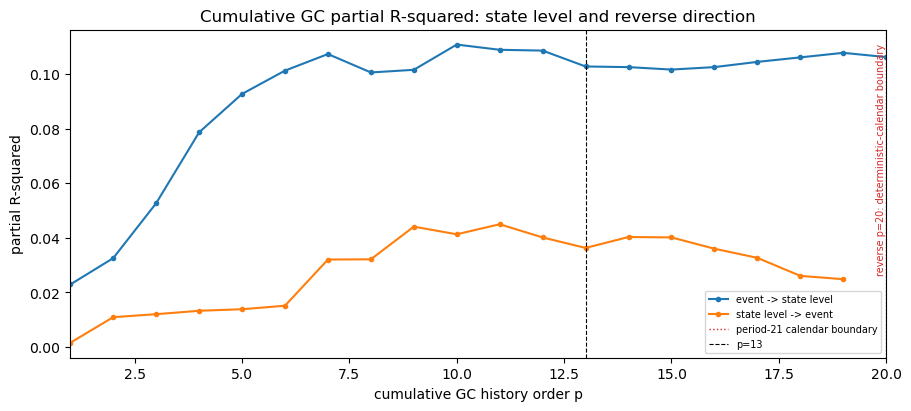

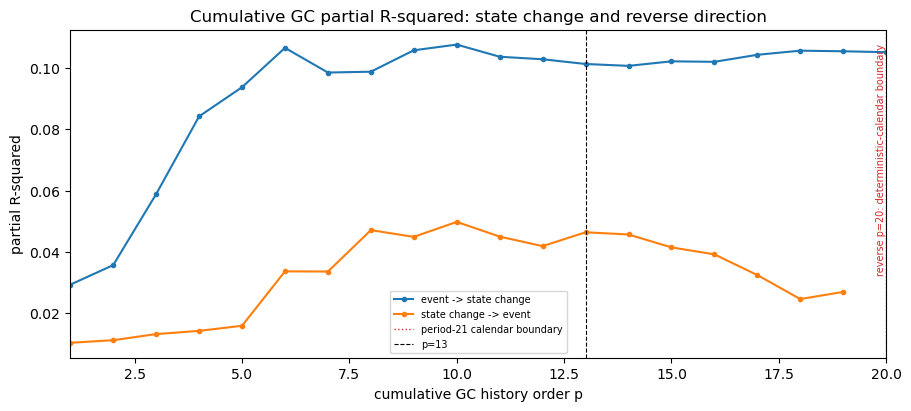

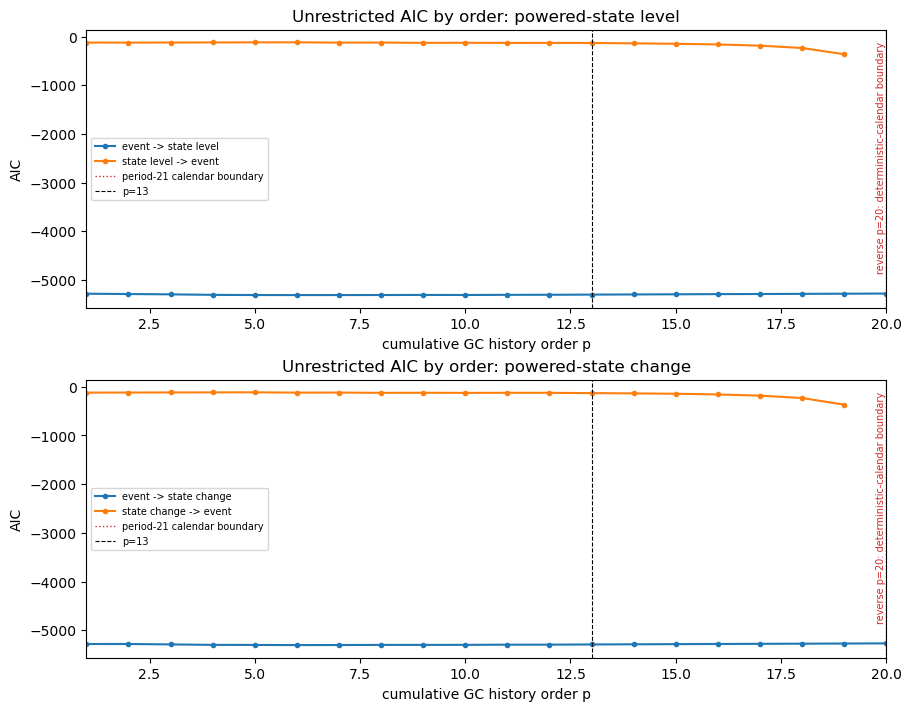

In [5]:
def mark_reverse_boundary(ax, data):
    boundary = data.loc[data.excluded_from_selection]
    if not boundary.empty:
        ax.axvline(INTER_EVENT_END, color='tab:red', linestyle=':', linewidth=1, label='period-21 calendar boundary')
        ax.annotate('reverse p=20: deterministic-calendar boundary', xy=(INTER_EVENT_END, .96), xycoords=('data','axes fraction'), ha='right', va='top', rotation=90, fontsize=7, color='tab:red')

def plot_gc_orders(target_name,title):
    data=gc_scan.loc[gc_scan.target.eq(target_name)]; fig,ax=plt.subplots(figsize=(9,4),constrained_layout=True)
    for direction,subset in data.groupby('direction'):
        ax.plot(subset.lag_order,subset.partial_R_squared,marker='o',markersize=3,label=direction)
        mark_reverse_boundary(ax, subset)
    ax.axvline(DIRECT_END,color='black',linestyle='--',linewidth=.8,label='p=13')
    ax.set(title=title,xlabel='cumulative GC history order p',ylabel='partial R-squared',xlim=(1,GC_MAX_ORDER)); ax.legend(fontsize=7); plt.show()
plot_gc_orders('Powered-state level','Cumulative GC partial R-squared: state level and reverse direction')
plot_gc_orders('Powered-state change','Cumulative GC partial R-squared: state change and reverse direction')
fig,axes=plt.subplots(2,1,figsize=(9,7),constrained_layout=True)
for ax,target_name in zip(axes,['Powered-state level','Powered-state change']):
    for direction,subset in gc_scan.loc[gc_scan.target.eq(target_name)].groupby('direction'):
        ax.plot(subset.lag_order,subset.unrestricted_AIC,marker='o',markersize=3,label=direction)
        mark_reverse_boundary(ax, subset)
    ax.axvline(DIRECT_END,color='black',linestyle='--',linewidth=.8,label='p=13')
    ax.set(title=f'Unrestricted AIC by order: {target_name.lower()}',xlabel='cumulative GC history order p',ylabel='AIC',xlim=(1,GC_MAX_ORDER)); ax.legend(fontsize=7)
plt.show()


## 5. Individual driver-lag contributions within GC

The full distributed-lag model retains target-history terms and all driver lags: $b_1D_{t-1}+b_2D_{t-2}+\cdots+b_PD_{t-P}$. For each driver lag $j$, the displayed partial-F statistic tests $H_0:b_j=0$ while retaining all target lags and the other driver lags.

> **Each stem measures the conditional linear predictive contribution of one included driver lag. The tallest stem does not identify an amount of causality and does not necessarily identify a unique structural causal delay.**

For a single coefficient restriction, the partial F-statistic is the square of the corresponding t-statistic.


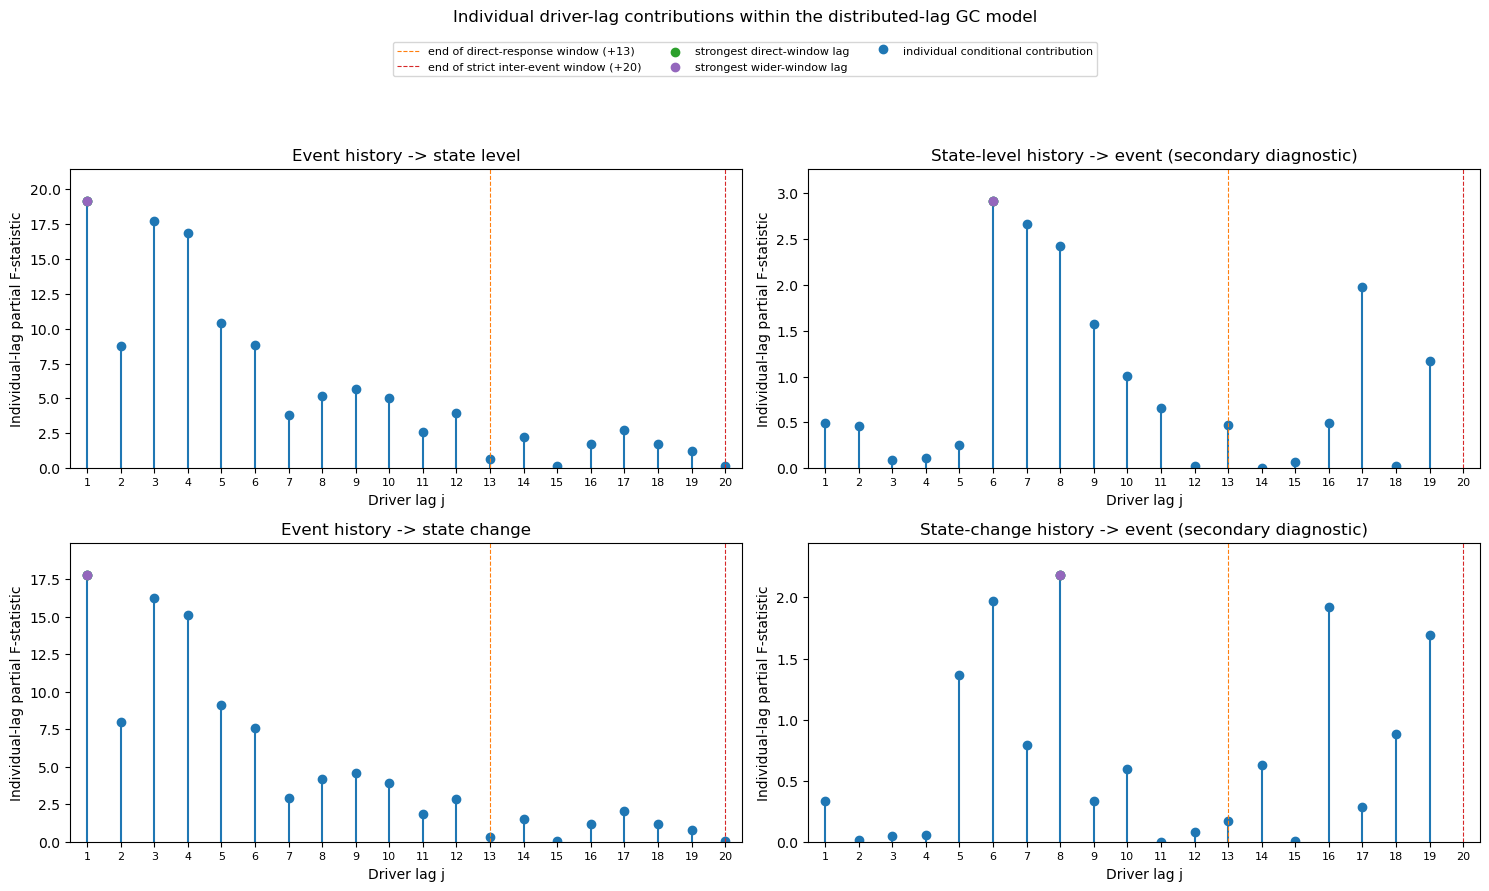

In [6]:
fig,axes=plt.subplots(2,2,figsize=(15,9))
fig.suptitle('Individual driver-lag contributions within the distributed-lag GC model',y=0.985)
panel_titles={'event -> state level':'Event history -> state level','state level -> event':'State-level history -> event (secondary diagnostic)','event -> state change':'Event history -> state change','state change -> event':'State-change history -> event (secondary diagnostic)'}
for ax,(_,direction,_,_) in zip(axes.ravel(),gc_specs):
    data=individual_lag_table.loc[individual_lag_table.direction.eq(direction)]
    ax.stem(data.lag,data.partial_F_statistic,basefmt=' ',label='individual conditional contribution')
    ax.axvline(DIRECT_END,color='tab:orange',linestyle='--',linewidth=.8,label='end of direct-response window (+13)')
    ax.axvline(INTER_EVENT_END,color='tab:red',linestyle='--',linewidth=.8,label='end of strict inter-event window (+20)')
    inter_label=f"valid inter-event lag=1..{GC_MAX_ORDER-1 if direction in REVERSE_GC_DIRECTIONS else GC_MAX_ORDER}"
    for label,color,legend_label in [('direct response lag=1..13','tab:green','strongest direct-window lag'),(inter_label,'tab:purple','strongest wider-window lag')]:
        row=strongest_individual_lag_table.loc[(strongest_individual_lag_table.direction.eq(direction))&(strongest_individual_lag_table['lag window'].eq(label))].iloc[0]
        ax.scatter(row['strongest lag'],row['partial F-statistic'],color=color,zorder=4,label=legend_label)
    panel_max=(data['partial_F_statistic'].replace([np.inf,-np.inf],np.nan).max())
    if pd.notna(panel_max) and panel_max>0:
        ax.set_ylim(0,panel_max*1.12)
    else:
        ax.set_ylim(bottom=0)
    ax.set(title=panel_titles[direction],xlabel='Driver lag j',ylabel='Individual-lag partial F-statistic')
    ax.set_xlim(0.5,GC_MAX_ORDER+0.5)
    ax.set_xticks(np.arange(1,GC_MAX_ORDER+1))
    ax.tick_params(axis='x',labelsize=8)
handles,labels=axes.flat[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5,0.955),ncol=3,fontsize=8,frameon=True)
fig.tight_layout(rect=(0,0,1,0.88))
plt.show()


### Reading the individual-lag figure

The orange reference line marks the end of the Known-DGP direct-response window (+13); the red line marks the end of the strict inter-event window (+20), immediately before the next periodic event boundary (+21). Green and purple highlights identify the strongest included driver lag within these respective windows. If they overlap, the later-drawn marker can cover the earlier one.

Taller stems mean a stronger conditional linear predictive contribution within the full GC model. They are conditional on all other included regressors, are not the main joint GC test, and do not measure an amount of structural causality.


In [7]:
forward_examples=strongest_individual_lag_table.loc[(strongest_individual_lag_table.direction.isin(['event -> state level','event -> state change']))&(strongest_individual_lag_table['lag window'].eq('direct response lag=1..13'))]
for _,row in forward_examples.iterrows(): print(f"Worked forward diagnostic - {row['direction']}: largest individual partial F occurs at driver lag {int(row['strongest lag'])} within the direct-response window.")
print('Interpretation: D_(t-j) makes the strongest separate linear predictive contribution within the fitted distributed-lag model after controlling for remaining histories. It does not mean the event first affects the state after j periods. Under the Known-DGP timing E_t -> omega_(t+1) -> X_(t+1), the direct response begins one transition later; persistence and correlated event-lag regressors can distribute predictive contribution across later neighbouring lags.')


Worked forward diagnostic - event -> state level: largest individual partial F occurs at driver lag 1 within the direct-response window.
Worked forward diagnostic - event -> state change: largest individual partial F occurs at driver lag 1 within the direct-response window.
Interpretation: D_(t-j) makes the strongest separate linear predictive contribution within the fitted distributed-lag model after controlling for remaining histories. It does not mean the event first affects the state after j periods. Under the Known-DGP timing E_t -> omega_(t+1) -> X_(t+1), the direct response begins one transition later; persistence and correlated event-lag regressors can distribute predictive contribution across later neighbouring lags.


## 6. Reverse predictive diagnostics

The forward panels - event history to state level and event history to state change?are the primary synthetic question. The reverse panels are secondary diagnostics.

> The event schedule is deterministic and periodic. Past state observations may therefore contain information about calendar phase. Reverse predictability does not imply that the volatility state structurally causes a scheduled event.

The period-21 boundary treatment in the cumulative results remains a calendar-phase diagnostic.


## 7. Time-delayed mutual information

GC asks whether driver history adds **linear predictive information** after conditioning on target history. TDMI measures general pairwise statistical dependence at signed temporal displacements and can reveal nonlinear dependence that linear GC may miss. Ordinary TDMI does not condition on the target?s own history in the same way as GC, so it is not conditional Granger causality.

The implemented convention is: at positive lag $k$, the event driver at time $t-k$ is compared with the target at time $t$. Positive lags therefore represent the driver preceding the target. For example, a TDMI peak at +3 means strongest measured dependence when the driver is placed three observations before the target. A TDMI peak is a dependence peak, not automatically a structural causal delay.


### TDMI estimator and signed lag

The primary estimator applies fixed empirical quantile edges from `qcut` using the inherited primary setting of 10 bins and calculates $I(E_i;Y_{i+tau})$ directly from contingency-table probabilities. Mutual information is symmetric; signed lag supplies temporal interpretation.


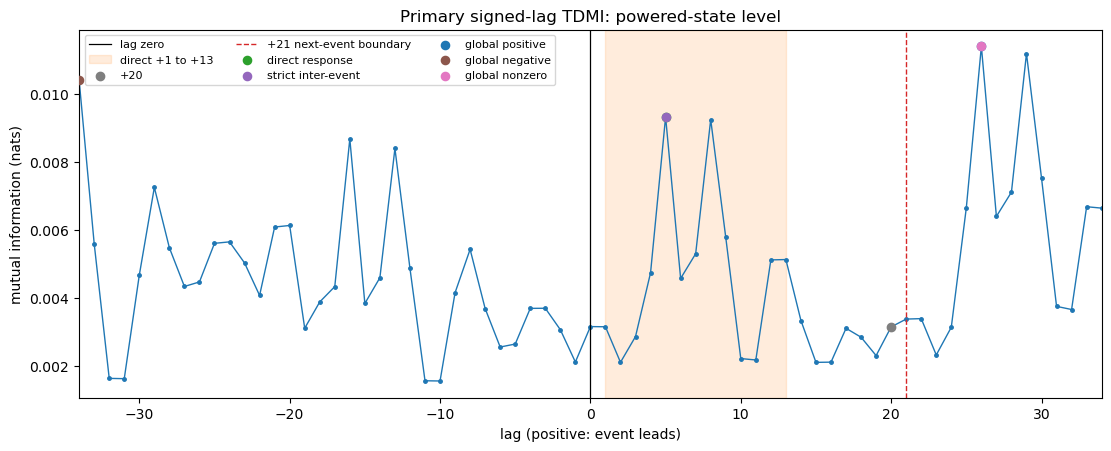

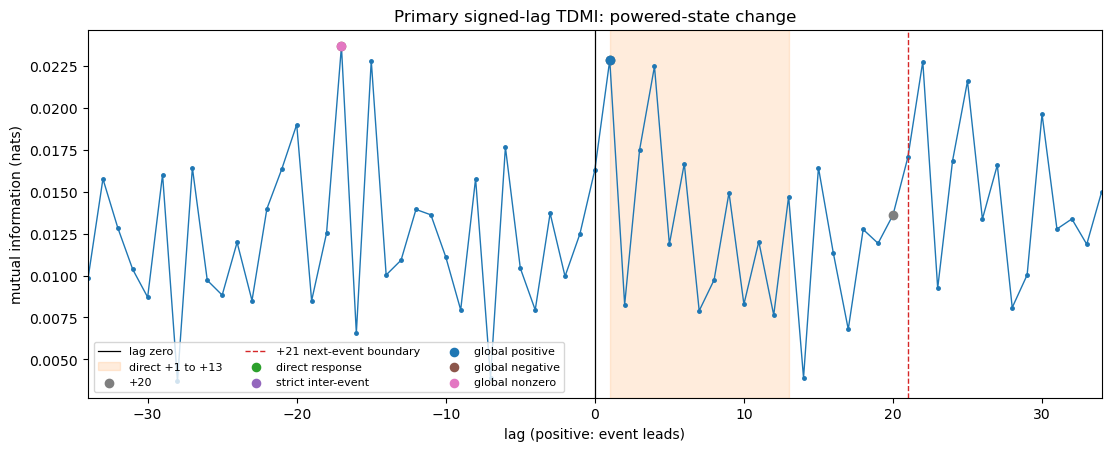

In [8]:
def tdmi_pairs(event,target,lag):
    event,target=np.asarray(event,int),np.asarray(target,float)
    return (event[:-lag],target[lag:]) if lag>0 else ((event[-lag:],target[:lag]) if lag<0 else (event,target))
def fixed_quantile_edges(values,bins):
    _,edges=pd.qcut(pd.Series(values,dtype=float),q=bins,retbins=True,duplicates='drop'); edges=np.asarray(edges,float)
    if len(edges)<3: raise ValueError('fewer than two TDMI bins.')
    edges[0],edges[-1]=-np.inf,np.inf; return edges
def mi_from_counts(event,bins):
    counts=pd.crosstab(pd.Series(event),pd.Series(bins),dropna=False).to_numpy(float); joint=counts/counts.sum(); independent=joint.sum(1,keepdims=True)@joint.sum(0,keepdims=True); nonzero=joint>0
    return float(np.sum(joint[nonzero]*np.log(joint[nonzero]/independent[nonzero])))
def compute_tdmi_curve(event,target,bins=10):
    edges=fixed_quantile_edges(target,bins); rows=[]
    for lag in range(-TDMI_MAX_LAG,TDMI_MAX_LAG+1):
        e,y=tdmi_pairs(event,target,lag); b=pd.cut(pd.Series(y),bins=edges,labels=False,include_lowest=True); rows.append({'lag':lag,'n_pairs':len(e),'mutual_information':mi_from_counts(e,b.to_numpy(int))})
    return pd.DataFrame(rows)
def summarise_tdmi_windows(curve,target_name):
    windows=[('direct response',1,DIRECT_END,'event response'),('strict inter-event',1,INTER_EVENT_END,'before next event'),('next-event boundary',NEXT_EVENT_BOUNDARY,NEXT_EVENT_BOUNDARY,'next scheduled event'),('global positive',1,TDMI_MAX_LAG,'event leads target'),('global negative',-TDMI_MAX_LAG,-1,'target leads event'),('global nonzero',-TDMI_MAX_LAG,TDMI_MAX_LAG,'largest nonzero dependence'),('lag zero',0,0,'contemporaneous dependence')]; rows=[]
    for window,lo,hi,text in windows:
        data=curve.loc[curve.lag.between(lo,hi)]; data=data.loc[data.lag.ne(0)] if window=='global nonzero' else data; best=data.nlargest(1,'mutual_information').iloc[0]; boundary=bool(best.lag in {-TDMI_MAX_LAG,TDMI_MAX_LAG})
        rows.append({'target':target_name,'window':window,'best lag':int(best.lag),'TDMI value':float(best.mutual_information),'boundary maximum':boundary,'interpretation':text+('; scan-boundary maximum' if boundary else '')})
    return pd.DataFrame(rows)
def plot_tdmi_curve(curve,summary,target_name):
    fig,ax=plt.subplots(figsize=(11,4.4),constrained_layout=True); ax.plot(curve.lag,curve.mutual_information,marker='o',markersize=2.5,linewidth=1); ax.axvline(0,color='black',linewidth=.9,label='lag zero'); ax.axvspan(1,DIRECT_END,color='tab:orange',alpha=.14,label='direct +1 to +13')
    at20=curve.loc[curve.lag.eq(INTER_EVENT_END)].iloc[0]; ax.scatter(INTER_EVENT_END,at20.mutual_information,color='tab:gray',zorder=4,label='+20'); ax.axvline(NEXT_EVENT_BOUNDARY,color='tab:red',linestyle='--',linewidth=1,label='+21 next-event boundary')
    for window,color in {'direct response':'tab:green','strict inter-event':'tab:purple','global positive':'tab:blue','global negative':'tab:brown','global nonzero':'tab:pink'}.items():
        row=summary.loc[summary.window.eq(window)].iloc[0]; ax.scatter(row['best lag'],row['TDMI value'],color=color,s=35,zorder=5,label=window)
    ax.set(title=f'Primary signed-lag TDMI: {target_name}',xlabel='lag (positive: event leads)',ylabel='mutual information (nats)',xlim=(-TDMI_MAX_LAG,TDMI_MAX_LAG)); ax.legend(ncol=3,fontsize=8); plt.show()
level_tdmi=compute_tdmi_curve(level_table.event,level_table.state); level_tdmi_summary=summarise_tdmi_windows(level_tdmi,'Powered-state level'); plot_tdmi_curve(level_tdmi,level_tdmi_summary,'powered-state level')
change_tdmi=compute_tdmi_curve(change_table.event,change_table.state_change); change_tdmi_summary=summarise_tdmi_windows(change_tdmi,'Powered-state change'); plot_tdmi_curve(change_tdmi,change_tdmi_summary,'powered-state change')


### TDMI results

The curves below use the pre-specified fixed 10-bin estimator. Interpret peaks as signed-lag dependence, with caution about periodicity, persistence, finite-sample effects, and scan-boundary maxima. Forward and reverse-looking peaks can coexist without establishing structural reverse causation.


In [9]:
tdmi_best_lag_table=pd.concat([level_tdmi_summary,change_tdmi_summary],ignore_index=True)
print('TDMI best lags by pre-specified window'); display(tdmi_best_lag_table.style.format({'TDMI value':'{:.6f}'}))


TDMI best lags by pre-specified window


,target,window,best lag,TDMI value,boundary maximum,interpretation
0,Powered-state level,direct response,5,0.009329,False,event response
1,Powered-state level,strict inter-event,5,0.009329,False,before next event
2,Powered-state level,next-event boundary,21,0.003377,False,next scheduled event
3,Powered-state level,global positive,26,0.011406,False,event leads target
4,Powered-state level,global negative,-34,0.010405,True,target leads event; scan-boundary maximum
5,Powered-state level,global nonzero,26,0.011406,False,largest nonzero dependence
6,Powered-state level,lag zero,0,0.003156,False,contemporaneous dependence
7,Powered-state change,direct response,1,0.022854,False,event response
8,Powered-state change,strict inter-event,1,0.022854,False,before next event
9,Powered-state change,next-event boundary,21,0.017061,False,next scheduled event


## 8. GC and TDMI comparison

| Feature | GC | TDMI |
|---|---|---|
| Main object | Incremental prediction | Lagged statistical dependence |
| Functional sensitivity | Linear under current implementation | Can capture nonlinear dependence |
| Conditions on target history | Yes | Not in ordinary pairwise TDMI |
| Directional evidence | Through predictive improvement | Through signed-lag asymmetry |
| Main limitation here | Linear specification and correlated lags | Periodicity, finite-sample bias and lack of conditioning |
| Safe interpretation | Granger-predictive relationship | Lagged statistical dependence |

> GC history order, individual partial-F peak, and TDMI peak are not expected to be numerically identical because they answer different statistical questions.


### TDMI sensitivity and validation checks

The 10-bin TDMI curve is primary because it was fixed before inspection. The small 5/10/15-bin table is a sensitivity diagnostic, not a data-driven estimator choice. Silent assertions cover timing, common samples, leakage protection, Holm adjustment and prior benchmark reproduction.


In [10]:
sensitivity_rows=[]
for target_name,event,target in [('Powered-state level',level_table.event,level_table.state),('Powered-state change',change_table.event,change_table.state_change)]:
    for bins in (5,10,15):
        summary=summarise_tdmi_windows(compute_tdmi_curve(event,target,bins),target_name).set_index('window'); sensitivity_rows.append({'target':target_name,'quantile bins':bins,'direct peak lag':int(summary.loc['direct response','best lag']),'direct peak TDMI':float(summary.loc['direct response','TDMI value']),'inter-event peak lag':int(summary.loc['strict inter-event','best lag']),'inter-event peak TDMI':float(summary.loc['strict inter-event','TDMI value']),'global positive peak lag':int(summary.loc['global positive','best lag']),'global positive peak TDMI':float(summary.loc['global positive','TDMI value']),'global negative peak lag':int(summary.loc['global negative','best lag']),'global negative peak TDMI':float(summary.loc['global negative','TDMI value'])})
tdmi_sensitivity_table=pd.DataFrame(sensitivity_rows); display(tdmi_sensitivity_table.style.format({col:'{:.6f}' for col in tdmi_sensitivity_table if 'TDMI' in col}))

,target,quantile bins,direct peak lag,direct peak TDMI,inter-event peak lag,inter-event peak TDMI,global positive peak lag,global positive peak TDMI,global negative peak lag,global negative peak TDMI
0,Powered-state level,5,1,0.002223,1,0.002223,22,0.002397,-20,0.003303
1,Powered-state level,10,5,0.009329,5,0.009329,26,0.011406,-34,0.010405
2,Powered-state level,15,10,0.015953,20,0.016155,31,0.016950,-32,0.016731
3,Powered-state change,5,3,0.015729,3,0.015729,3,0.015729,-17,0.015299
4,Powered-state change,10,1,0.022854,1,0.022854,1,0.022854,-17,0.023674
5,Powered-state change,15,1,0.024451,1,0.024451,30,0.027137,-15,0.024862


## 9. Main interpretation and limitations

GC provides joint linear predictive evidence; individual partial-F stems describe conditional contributions inside that fitted model. TDMI is a pairwise dependence diagnostic. Reverse results may reflect calendar-phase predictability under a deterministic periodic schedule, not state-to-event structural causation.


## 10. Validation summary and how to read the outputs

- **Joint GC significance:** Does the driver history collectively improve prediction?
- **Selected GC order:** How much history does the selected linear model include?
- **Largest individual partial-F lag:** Which one included driver lag has the strongest conditional linear predictive contribution?
- **TDMI peak lag:** At which signed displacement is pairwise dependence strongest?
- **Known-DGP direct-response timing:** When the simulator actually applies the event effect.

> None of the first four quantities should automatically be called the true causal lag. Only the Known-DGP timing is known by construction in the synthetic experiment.


In [11]:
def legacy_one_lag_forward_f(target,driver):
    y=np.asarray(target,float)[1:]; yl=np.asarray(target,float)[:-1]; dl=np.asarray(driver,float)[:-1]; r=sm.OLS(y,sm.add_constant(yl)).fit(); u=sm.OLS(y,sm.add_constant(np.column_stack([yl,dl]))).fit(); return float((r.ssr-u.ssr)/(u.ssr/u.df_resid))
old={'level_p1_F':12.094457,'change_p1_F':14.862315,'level_direct_lag':5,'level_direct_TDMI':.009329,'change_direct_lag':1,'change_direct_TDMI':.022854}
level_f=legacy_one_lag_forward_f(level_table.state,level_table.event); change_f=legacy_one_lag_forward_f(change_table.state_change,change_table.event); level_direct=tdmi_best_lag_table.loc[(tdmi_best_lag_table.target.eq('Powered-state level'))&(tdmi_best_lag_table.window.eq('direct response'))].iloc[0]; change_direct=tdmi_best_lag_table.loc[(tdmi_best_lag_table.target.eq('Powered-state change'))&(tdmi_best_lag_table.window.eq('direct response'))].iloc[0]
assert all(scan.n_observations.nunique()==1 for _,scan in gc_scan.groupby('direction')) and DIRECT_END==13 and INTER_EVENT_END==20 and NEXT_EVENT_BOUNDARY==21
assert set(gc_scan.direction)=={spec[1] for spec in gc_specs} and np.array_equal(level_tdmi.lag,np.arange(-34,35)) and np.array_equal(change_tdmi.lag,np.arange(-34,35))
assert individual_lag_table.Holm_adjusted_p_value.notna().all() and not gc_order_selection_table.empty and not strongest_individual_lag_table.empty and not tdmi_best_lag_table.empty
assert np.isclose(level_f,old['level_p1_F'],rtol=1e-6) and np.isclose(change_f,old['change_p1_F'],rtol=1e-6)
assert int(level_direct['best lag'])==old['level_direct_lag'] and np.isclose(level_direct['TDMI value'],old['level_direct_TDMI'],atol=1e-6) and int(change_direct['best lag'])==old['change_direct_lag'] and np.isclose(change_direct['TDMI value'],old['change_direct_TDMI'],atol=1e-6)
reverse_boundary=gc_scan.loc[gc_scan.direction.isin(REVERSE_GC_DIRECTIONS)&gc_scan.lag_order.eq(GC_MAX_ORDER)]; forward_boundary=gc_scan.loc[~gc_scan.direction.isin(REVERSE_GC_DIRECTIONS)&gc_scan.lag_order.eq(GC_MAX_ORDER)]
assert reverse_boundary.reverse_calendar_boundary.all() and reverse_boundary.excluded_from_selection.all()
assert not forward_boundary.excluded_from_selection.any()
assert not gc_order_selection_table.loc[gc_order_selection_table.direction.isin(REVERSE_GC_DIRECTIONS),['AIC-selected order','BIC-selected order','max-partial-R2 order']].eq(GC_MAX_ORDER).any().any()
assert not strongest_individual_lag_table.loc[strongest_individual_lag_table.direction.isin(REVERSE_GC_DIRECTIONS),'strongest lag'].eq(GC_MAX_ORDER).any()
print('Reverse-GC period-21 calendar boundary handled correctly.')

Reverse-GC period-21 calendar boundary handled correctly.


### Result-specific interpretation

GC is predictive causality, not proof of structural causation. Reverse GC can reflect deterministic event-calendar phase; individual distributed-lag coefficients can be unstable under multicollinearity. TDMI is a dependence measure, not proof of structural causality; negative-lag dependence can arise through persistence and periodicity, while scan-boundary maxima and post-hoc scanning require caution.


In [12]:
import nbformat
def compact_selection(direction): return '; '.join(f"{r['search window']}: AIC p={int(r['AIC-selected order'])}, BIC p={int(r['BIC-selected order'])}" for _,r in gc_order_selection_table.loc[gc_order_selection_table.direction.eq(direction)].iterrows())
def compact_lags(direction): return '; '.join(f"{r['lag window']}: lag {int(r['strongest lag'])}, Holm={'yes' if r['survives Holm correction'] else 'no'}" for _,r in strongest_individual_lag_table.loc[strongest_individual_lag_table.direction.eq(direction)].iterrows())
def compact_tdmi(target):
    r=tdmi_best_lag_table.loc[tdmi_best_lag_table.target.eq(target)].set_index('window'); return f"direct {int(r.loc['direct response','best lag'])}, inter-event {int(r.loc['strict inter-event','best lag'])}, positive {int(r.loc['global positive','best lag'])}, negative {int(r.loc['global negative','best lag'])}, nonzero global {int(r.loc['global nonzero','best lag'])}"
text=f"""### Result-specific conclusions

- Event to state level: {compact_selection('event -> state level')}; strongest conditional lags are {compact_lags('event -> state level')}.
- State level to event: {compact_selection('state level -> event')}; reverse GC is a calendar-phase diagnostic, not structural state-to-event causation. With the deterministic period-21 schedule, 20 previous event values encode the cycle position. Reverse p=20 is therefore excluded whether or not startup alignment prevents restricted RSS from becoming exactly zero; reverse cumulative and individual-lag inference use only p=1..19, while lag 20 remains a visible calendar boundary. Strongest lags are {compact_lags('state level -> event')}.
- Event to state change: {compact_selection('event -> state change')}; strongest conditional lags are {compact_lags('event -> state change')}.
- State change to event: {compact_selection('state change -> event')}; strongest lags are {compact_lags('state change -> event')}, again without a structural reverse-causation claim; any numerically degenerate p=20 deterministic-calendar boundary is excluded from inference.
- TDMI peak lags for level are {compact_tdmi('Powered-state level')}. TDMI peak lags for change are {compact_tdmi('Powered-state change')}. Forward GC remains the primary event-to-volatility predictive analysis; this reverse-GC boundary correction does not alter forward GC or TDMI. Direct/inter-event TDMI timing can differ from cumulative-GC order because they are different objects.

AIC is primary and BIC is parsimonious sensitivity; neither selected order identifies an individual structural delay. Individual-lag inference is Holm-adjusted, but adjacent periodic histories remain collinear. The 5/10/15-bin table makes descriptive TDMI peak sensitivity visible."""
display(Markdown(text))
source=nbformat.read("01_dense_periodic_n1_gc_tdmi.ipynb",as_version=4); original_code_lines=745; final_code_lines=sum(len(c.source.splitlines()) for c in source.cells if c.cell_type=='code'); reduction=100*(1-final_code_lines/original_code_lines)
print(f'Code lines: original approximately {original_code_lines}; final approximately {final_code_lines}; reduction {reduction:.1f}%; code cells {sum(c.cell_type=="code" for c in source.cells)}.')


### Result-specific conclusions

- Event to state level: direct response p=1..13: AIC p=6, BIC p=1; strict inter-event p=1..20: AIC p=6, BIC p=1; strongest conditional lags are direct response lag=1..13: lag 1, Holm=yes; valid inter-event lag=1..20: lag 1, Holm=yes.
- State level to event: direct response p=1..13: AIC p=13, BIC p=1; strict inter-event p=1..20: AIC p=19, BIC p=19; reverse GC is a calendar-phase diagnostic, not structural state-to-event causation. With the deterministic period-21 schedule, 20 previous event values encode the cycle position. Reverse p=20 is therefore excluded whether or not startup alignment prevents restricted RSS from becoming exactly zero; reverse cumulative and individual-lag inference use only p=1..19, while lag 20 remains a visible calendar boundary. Strongest lags are direct response lag=1..13: lag 6, Holm=no; valid inter-event lag=1..19: lag 6, Holm=no.
- Event to state change: direct response p=1..13: AIC p=6, BIC p=1; strict inter-event p=1..20: AIC p=6, BIC p=1; strongest conditional lags are direct response lag=1..13: lag 1, Holm=yes; valid inter-event lag=1..20: lag 1, Holm=yes.
- State change to event: direct response p=1..13: AIC p=13, BIC p=1; strict inter-event p=1..20: AIC p=19, BIC p=19; strongest lags are direct response lag=1..13: lag 8, Holm=no; valid inter-event lag=1..19: lag 8, Holm=no, again without a structural reverse-causation claim; any numerically degenerate p=20 deterministic-calendar boundary is excluded from inference.
- TDMI peak lags for level are direct 5, inter-event 5, positive 26, negative -34, nonzero global 26. TDMI peak lags for change are direct 1, inter-event 1, positive 1, negative -17, nonzero global -17. Forward GC remains the primary event-to-volatility predictive analysis; this reverse-GC boundary correction does not alter forward GC or TDMI. Direct/inter-event TDMI timing can differ from cumulative-GC order because they are different objects.

AIC is primary and BIC is parsimonious sensitivity; neither selected order identifies an individual structural delay. Individual-lag inference is Holm-adjusted, but adjacent periodic histories remain collinear. The 5/10/15-bin table makes descriptive TDMI peak sensitivity visible.

Code lines: original approximately 745; final approximately 194; reduction 74.0%; code cells 12.
